In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('mlflow').setLevel(logging.ERROR)

In [2]:
# Baseline Prophet model

# set MLflow experiment
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('NeuralRetail_Demand_Forecasting')

# load demand features data
df_demand = pd.read_parquet(r'../data/features/demand_features.parquet')

# Prophet requires 'ds' (date) and 'y' (value) column format
prophet_df = df_demand[['date', 'demand']].rename(
columns={'date': 'ds', 'demand': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

prophet_df = (prophet_df
              .set_index('ds')
              .resample('W')['y']
              .sum()
              .reset_index())

# cap outliers using 10th and 90th percentile
Q_low = prophet_df['y'].quantile(0.10)
Q_high = prophet_df['y'].quantile(0.90)
prophet_df['y'] = prophet_df['y'].clip(Q_low, Q_high)

# train/test split — last 4 weeks kept for testing
train_df = prophet_df[:-4].copy()
test_df = prophet_df[-4:].copy()
print(f'Train:{len(train_df)} days|Test:{len(test_df)}weeks')

Train:96 days|Test:4weeks


In [3]:
# start MLflow run and log parameters
mlflow.end_run()
run = mlflow.start_run(run_name='Prophet_Baseline')

params = {
    'changepoint_prior_scale': 0.5,
    'seasonality_prior_scale': 20.0,
    'seasonality_mode': 'multiplicative',
    'yearly_seasonality': True,
    'weekly_seasonality': False,
    'daily_seasonality': False,
}
mlflow.log_params(params)

In [4]:
# create and train Prophet model
model = Prophet(**params)

model.add_seasonality(
    name='monthly',
    period=4.3,
    fourier_order=5
)
model.fit(train_df)

03:12:33 - cmdstanpy - INFO - Chain [1] start processing
03:12:34 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
# generate forecast and calculate metrics
future = model.make_future_dataframe(periods=4, freq='W')
forecast = model.predict(future)

test_pred = np.maximum(forecast.tail(4)['yhat'].values, 0)
test_actual = test_df['y'].values

mape = mean_absolute_percentage_error(test_actual, test_pred) * 100
rmse = np.sqrt(np.mean((test_actual - test_pred)**2))
mae = np.mean(np.abs(test_actual - test_pred))

mlflow.log_metric('MAPE', round(mape, 2))
mlflow.log_metric('RMSE', round(rmse, 2))
mlflow.log_metric('MAE', round(mae, 2))

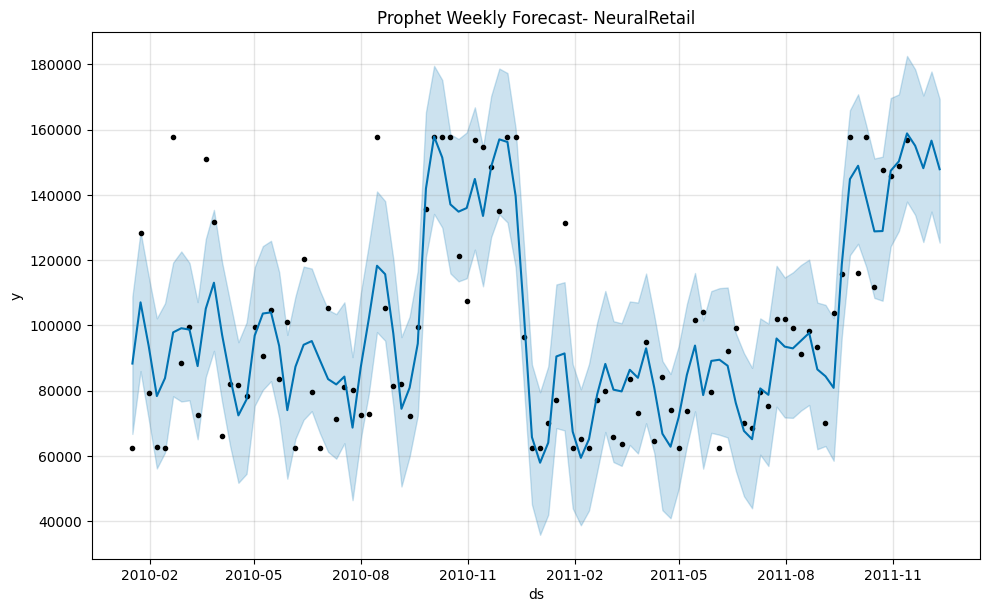

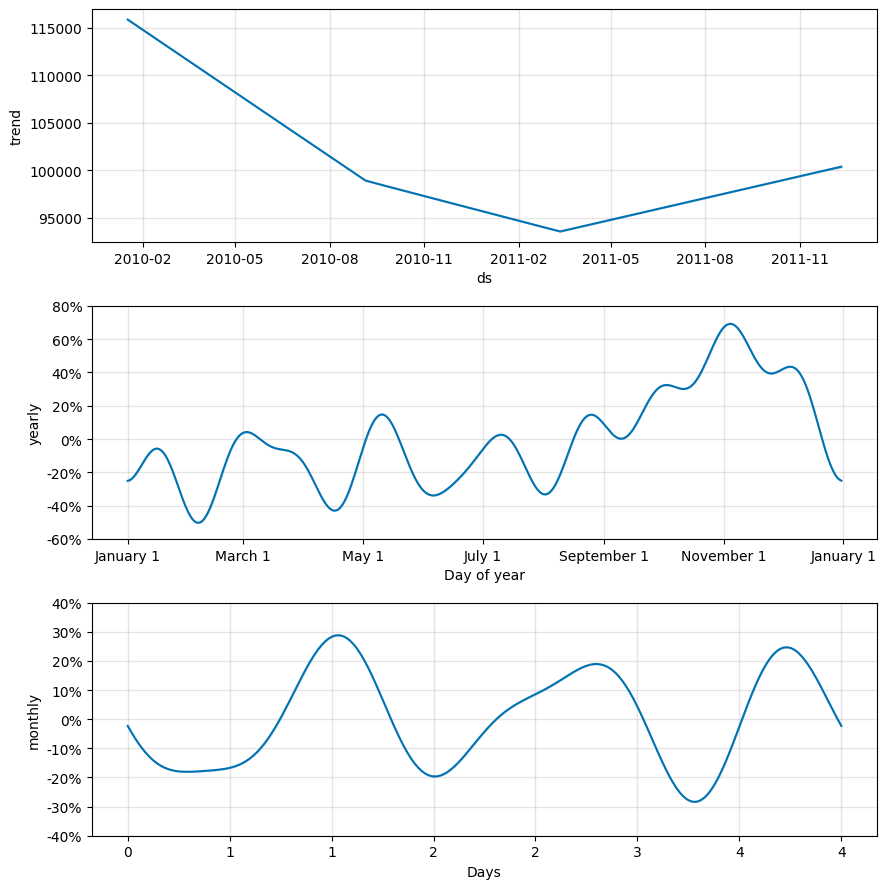

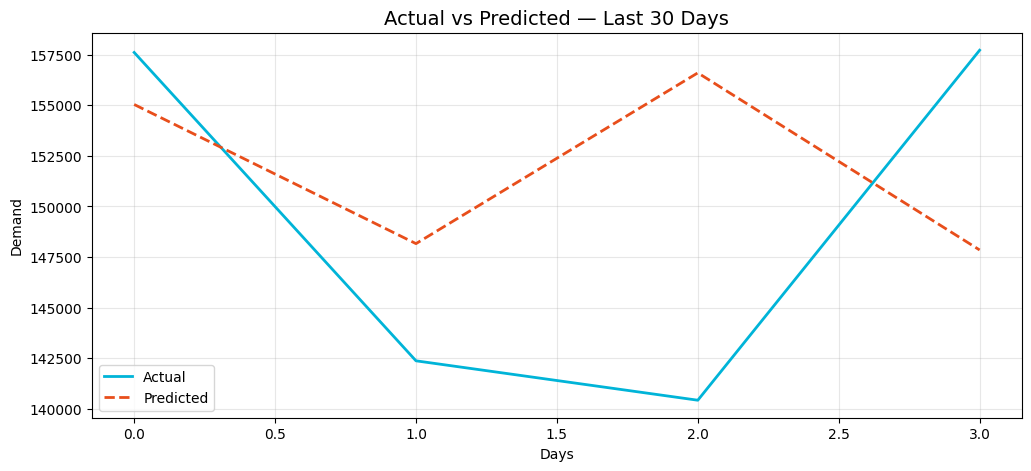

In [6]:
# forecast plot
fig1 = model.plot(forecast)
plt.title('Prophet Weekly Forecast- NeuralRetail')
fig1.savefig(r'../reports/prophet_forecast.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact(r'../reports/prophet_forecast.png')
plt.show()

# components plot showing trend and seasonality
fig2 = model.plot_components(forecast)
fig2.savefig(r'../reports/prophet_components.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact(r'../reports/prophet_components.png')
plt.show()

# actual vs predicted plot
fig3, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_actual, label='Actual', color='#00B4D8', linewidth=2)
ax.plot(test_pred, label='Predicted', color='#E84E1B', linewidth=2, linestyle='--')
ax.set_title('Actual vs Predicted — Last 30 Days', fontsize=14)
ax.set_xlabel('Days')
ax.set_ylabel('Demand')
ax.legend()
ax.grid(True, alpha=0.3)
fig3.savefig(r'../reports/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact(r'../reports/actual_vs_predicted.png')
plt.show()

In [7]:
# print results and register model in MLflow
print('=' * 40)
print(' Prophet Baseline Results')
print('=' * 40)
print(f' MAPE : {mape:.2f}% (Target: <= 10%)')
print(f' RMSE : {rmse:.0f}')
print(f' MAE  : {mae:.0f}')
print('=' * 40)

mlflow.prophet.log_model(
    model,
    artifact_path='prophet_model',
    registered_model_name='DemandForecast_Prophet'
)
print('Model registered in MLflow!')
mlflow.end_run()

 Prophet Baseline Results
 MAPE : 5.87% (Target: <= 10%)
 RMSE : 9995
 MAE  : 8606
Model registered in MLflow!
🏃 View run Prophet_Baseline at: http://localhost:5000/#/experiments/1/runs/48d610d7239540cf918832d6474caf9d
🧪 View experiment at: http://localhost:5000/#/experiments/1


Registered model 'DemandForecast_Prophet' already exists. Creating a new version of this model...
Created version '9' of model 'DemandForecast_Prophet'.
